In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_results(img_color_orig, img_gray_orig, img_gray_enh, img_color_enh, title):
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(title, fontsize=16)
    
    axs[0, 0].imshow(cv2.cvtColor(img_color_orig, cv2.COLOR_BGR2RGB))
    axs[0, 0].set_title('Original Colorida')
    axs[0, 0].axis('off')
    
    axs[0, 1].imshow(img_gray_orig, cmap='gray')
    axs[0, 1].set_title('Original em Escala de Cinza')
    axs[0, 1].axis('off')
    
    axs[1, 0].imshow(img_gray_enh, cmap='gray')
    axs[1, 0].set_title('Realçada em Escala de Cinza')
    axs[1, 0].axis('off')
    
    axs[1, 1].imshow(cv2.cvtColor(img_color_enh, cv2.COLOR_BGR2RGB))
    axs[1, 1].set_title('Realçada Colorida')
    axs[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

img_color = cv2.imread('gato.jpg')
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)


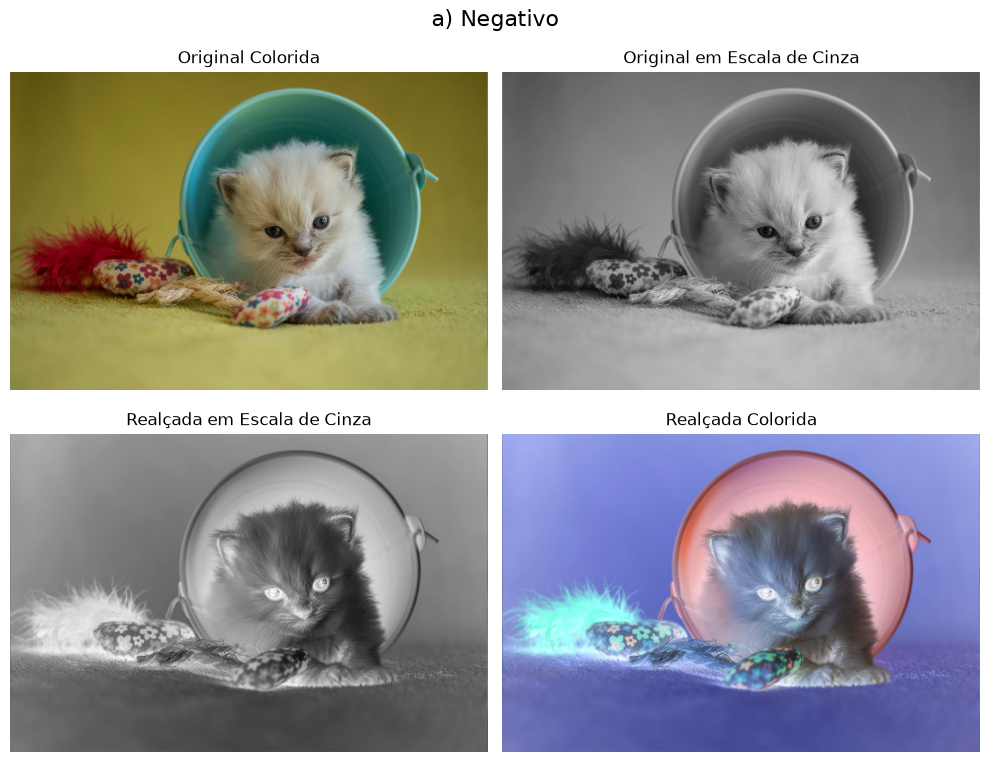

In [42]:
# a) Negativo da imagem
def negative_transform(img):
    return 255 - img

gray_neg = negative_transform(img_gray)
color_neg = negative_transform(img_color)
show_results(img_color, img_gray, gray_neg, color_neg, "a) Negativo")


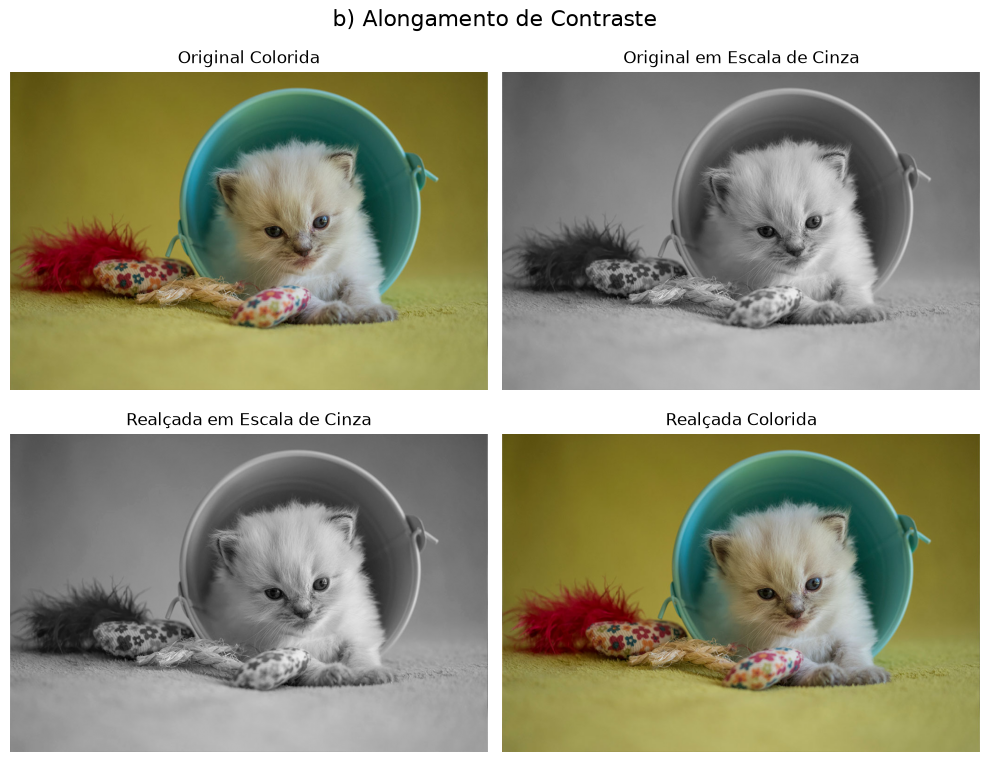

In [43]:
# b) Alongamento de contraste (contrast stretching)
def contrast_stretching(img, c=0, d=255):
    a = np.min(img)
    b = np.max(img)
    img_stretched = (img.astype(float) - a) * ((d - c) / (b - a + 1e-6)) + c
    return np.clip(img_stretched, 0, 255).astype(np.uint8)

gray_cs = contrast_stretching(img_gray, 0, 255)
color_cs = contrast_stretching(img_color, 0, 255)
show_results(img_color, img_gray, gray_cs, color_cs, "b) Alongamento de Contraste")


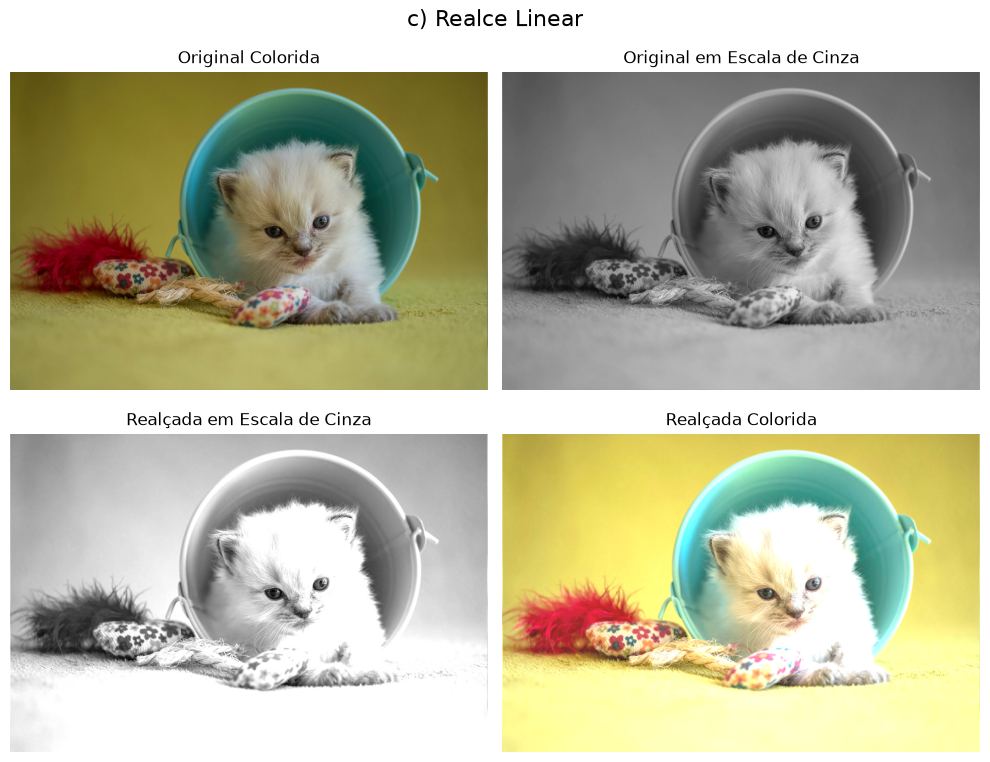

In [44]:
# c) Realce linear
def linear_transform(img, alpha, beta):
    res = alpha * img.astype(float) + beta
    return np.clip(res, 0, 255).astype(np.uint8)

gray_lin = linear_transform(img_gray, 1.5, 40)
color_lin = linear_transform(img_color, 1.5, 40)
show_results(img_color, img_gray, gray_lin, color_lin, "c) Realce Linear")


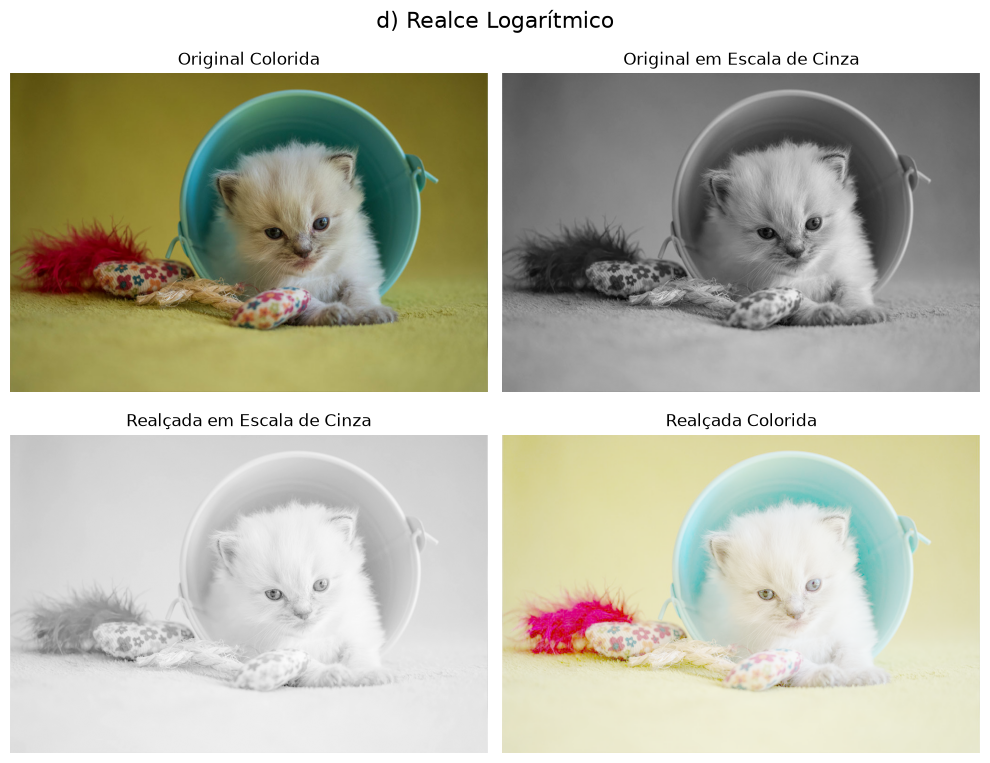

In [45]:
# d) Realce logarítmico
def log_transform(img, c):
    res = c * np.log(1 + img.astype(float))
    return np.clip(res, 0, 255).astype(np.uint8)

c_gray = 255.0 / np.log(1 + np.max(img_gray.astype(float)))
c_color = 255.0 / np.log(1 + np.max(img_color.astype(float)))
gray_log = log_transform(img_gray, c_gray)
color_log = log_transform(img_color, c_color)
show_results(img_color, img_gray, gray_log, color_log, "d) Realce Logarítmico")


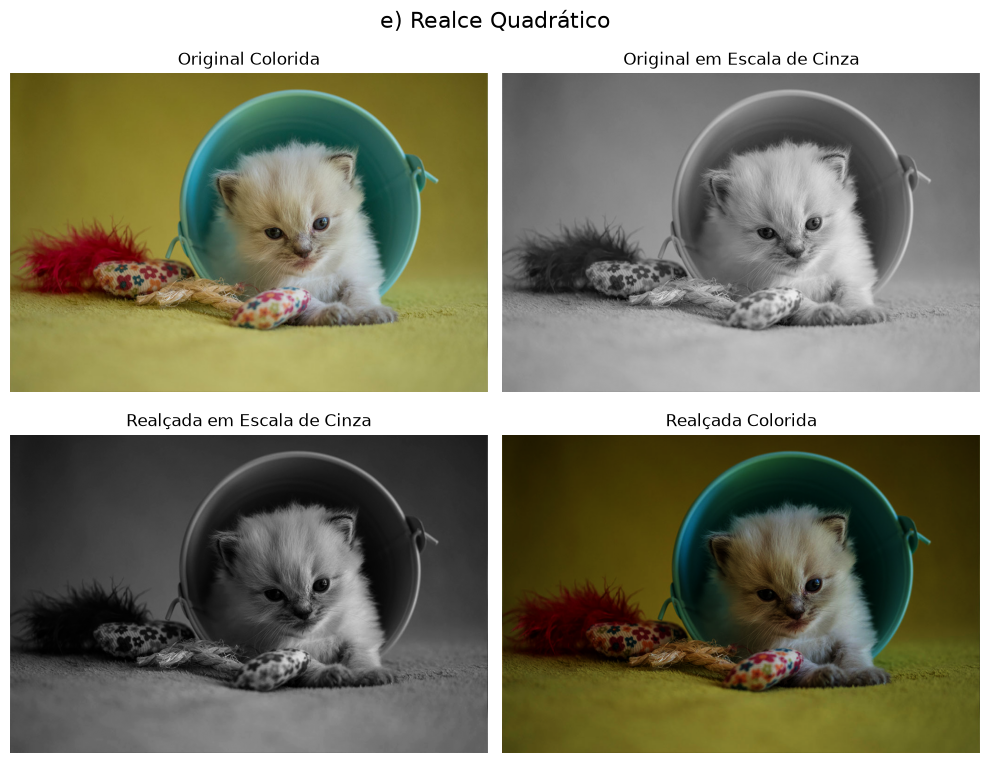

In [46]:
# e) Realce quadrático
def quadratic_transform(img, c):
    res = c * (img.astype(float) ** 2)
    return np.clip(res, 0, 255).astype(np.uint8)

gray_quad = quadratic_transform(img_gray, 1.0 / 255.0)
color_quad = quadratic_transform(img_color, 1.0 / 255.0)
show_results(img_color, img_gray, gray_quad, color_quad, "e) Realce Quadrático")


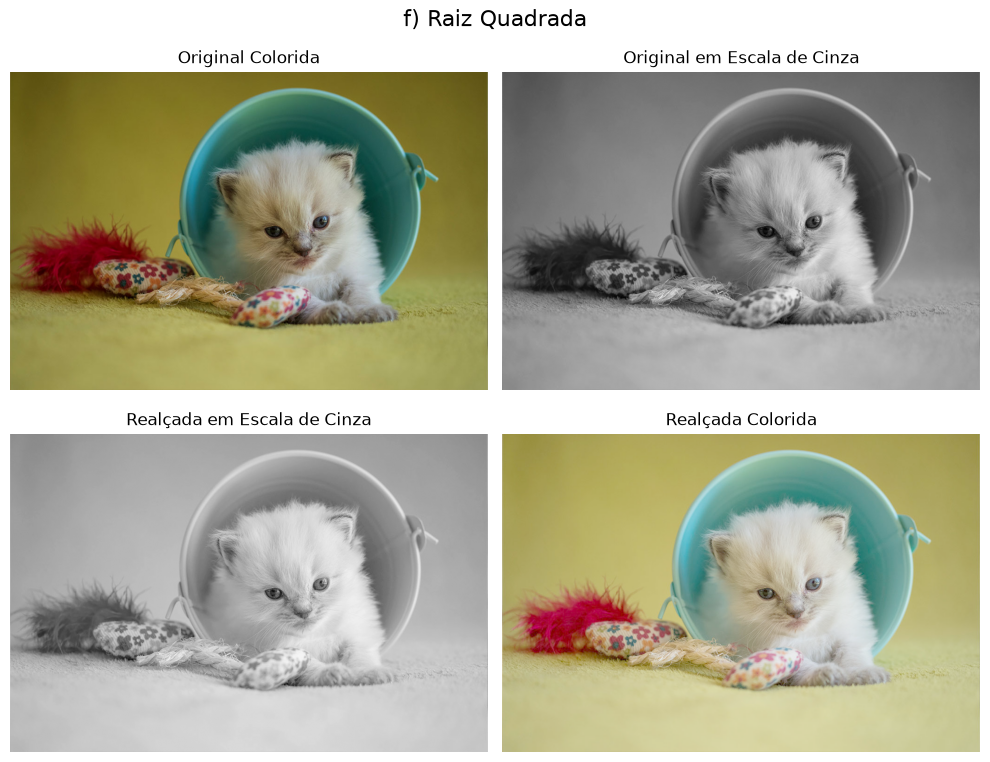

In [47]:
# f) Realce por raiz quadrada
def sqrt_transform(img, c):
    res = c * np.sqrt(img.astype(float))
    return np.clip(res, 0, 255).astype(np.uint8)

gray_sqrt = sqrt_transform(img_gray, 255.0 / np.sqrt(255.0))
color_sqrt = sqrt_transform(img_color, 255.0 / np.sqrt(255.0))
show_results(img_color, img_gray, gray_sqrt, color_sqrt, "f) Raiz Quadrada")


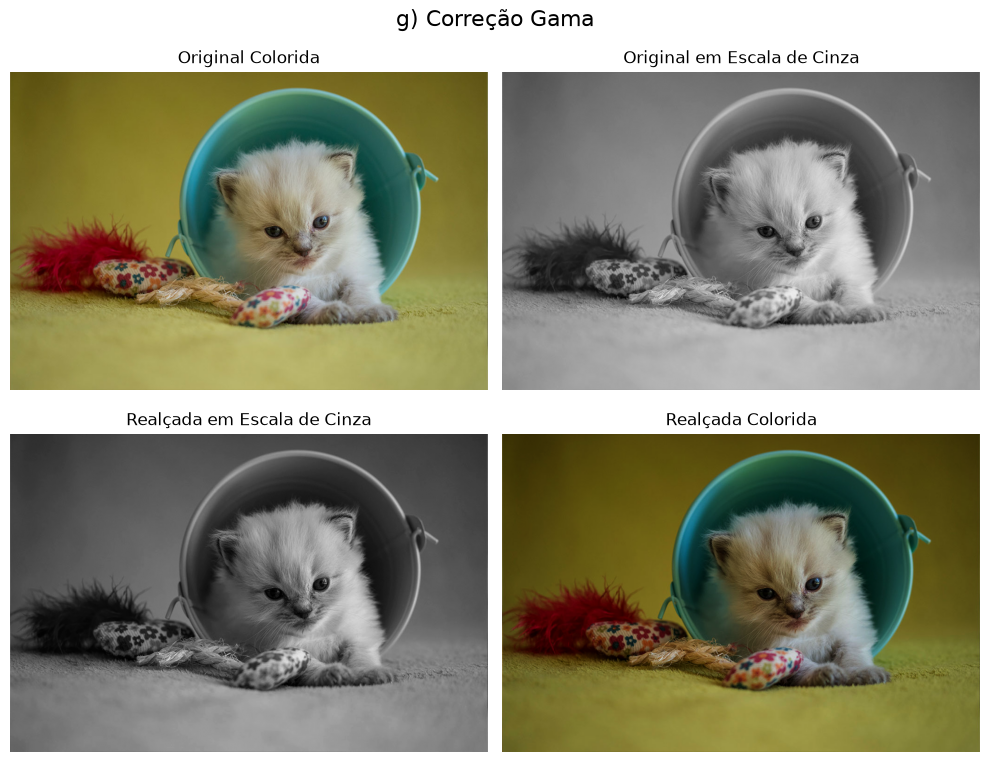

In [48]:
# g) Correção gama
def gamma_correction(img, gamma):
    res = 255.0 * ((img.astype(float) / 255.0) ** gamma)
    return np.clip(res, 0, 255).astype(np.uint8)

gray_gamma = gamma_correction(img_gray, 1.5)
color_gamma = gamma_correction(img_color, 1.5)
show_results(img_color, img_gray, gray_gamma, color_gamma, "g) Correção Gama")
